<a href="https://colab.research.google.com/github/meharalirajar060-codeee/Flyrank_Internship_ML_MAR/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meharalirajar060-codeee/Flyrank_Internship_ML_MAR/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [15]:
import duckdb, os, json
from google.colab import userdata

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
hf_token = userdata.get('HF_TOKEN')
con.execute(f"""CREATE SECRET hf_token (TYPE huggingface, TOKEN '{hf_token}');""")
FACT = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet"

data = con.execute(f"""
    WITH march AS (
        SELECT content_hash_id, client_hash_id,
               SUM(gsc_impressions) AS impressions_90d,
               SUM(gsc_clicks) AS clicks_90d,
               AVG(gsc_avg_position) AS avg_position_90d,
               DATE_DIFF('day', MAX(report_date), DATE '2026-03-31') AS days_since_last_seen
        FROM read_parquet('{FACT}')
        WHERE month = '2026-03'
        GROUP BY content_hash_id, client_hash_id
        HAVING SUM(gsc_impressions) >= 100
    ),
    april AS (
        SELECT content_hash_id, SUM(gsc_impressions) AS impressions_april
        FROM read_parquet('{FACT}') WHERE month = '2026-04' GROUP BY content_hash_id
    )
    SELECT m.*, COALESCE(a.impressions_april, 0) AS impressions_april
    FROM march m LEFT JOIN april a ON m.content_hash_id = a.content_hash_id
""").df()
data["ctr_90d"] = data["clicks_90d"] / data["impressions_90d"]
data["is_declining_label"] = (data["impressions_april"] < data["impressions_90d"] * 0.9).astype(int)
print(data.shape, data["is_declining_label"].mean())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(101441, 9) 0.5925809090998708


## 1. Question

*The research question and the decision it supports.*

In [16]:
"""Research question: which pages should a content reviewer look at first when review capacity is limited?

Decision this supports: which pages enter a reviewer's queue, and in what order. The unit of analysis is one content page, scored on its trailing 90-day (March) window of signals. The cost of a wrong call is asymmetric — ranking a low-value page too highly wastes minutes; missing a genuinely declining, high-traffic page means real opportunity goes unreviewed. This is why Precision@50 (evidence quality at the top of a capacity-limited queue) is the metric used throughout, rather than plain accuracy."""

"Research question: which pages should a content reviewer look at first when review capacity is limited?\n\nDecision this supports: which pages enter a reviewer's queue, and in what order. The unit of analysis is one content page, scored on its trailing 90-day (March) window of signals. The cost of a wrong call is asymmetric — ranking a low-value page too highly wastes minutes; missing a genuinely declining, high-traffic page means real opportunity goes unreviewed. This is why Precision@50 (evidence quality at the top of a capacity-limited queue) is the metric used throughout, rather than plain accuracy."

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [17]:
"""Release: FlyRank ML Internship warehouse (build flyrank_pseudonymized_warehouse_release_v20260703), table fact_content_daily_performance.

Feature window: month=2026-03 (mid-panel development month). Label window: month=2026-04 (forward-looking outcome, no overlap with features). Grain: one content page, one client, one day, rolled up to one row per page per month. Minimum volume filter: impressions_90d >= 100, to exclude near-zero-traffic noise.

Excluded, and why: product decision fields (health_score, priority_score, action_type) excluded on principle — feeding a product's own decision back in as a feature would let the model copy that decision instead of learning real signal (none of these are shipped in this dataset anyway). Raw query/URL/title/client-identifying fields excluded throughout, consistent with the release's pseudonymization. The release's final month (_sample, June 2026) was never used for feature-building or label logic, since it is the natural outcome window for any past-to-future label and using it would leak the target into development."""

print(data[["content_hash_id","client_hash_id","impressions_90d","days_since_last_seen"]].head())

            content_hash_id           client_hash_id  impressions_90d  \
0  content_143987cfdeaba4c0  client_62f4a7e64f5e0096            345.0   
1  content_86ab16840c4e0e1a  client_62f4a7e64f5e0096            854.0   
2  content_3f87f49c36774e23  client_62f4a7e64f5e0096            205.0   
3  content_64706c8afebebb8c  client_62f4a7e64f5e0096            666.0   
4  content_8809e466350d5b98  client_62f4a7e64f5e0096            174.0   

   days_since_last_seen  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [18]:
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

features = ["impressions_90d", "clicks_90d", "avg_position_90d", "ctr_90d", "days_since_last_seen"]
X = data[features].fillna(0)
y = data["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=data["client_hash_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Honest-split audit: naive vs grouped, side by side
X_tr_naive, X_te_naive, y_tr_naive, y_te_naive = train_test_split(X, y, test_size=0.2, random_state=42)
naive_model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42).fit(X_tr_naive, y_tr_naive)
naive_proba = naive_model.predict_proba(X_te_naive)[:, 1]
print("Naive split  -> AUC:", roc_auc_score(y_te_naive, naive_proba), "| P@50:", precision_at_k(naive_proba, y_te_naive.values, 50))

grouped_model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42).fit(X_train, y_train)
grouped_proba = grouped_model.predict_proba(X_test)[:, 1]
print("Grouped split-> AUC:", roc_auc_score(y_test, grouped_proba), "| P@50:", precision_at_k(grouped_proba, y_test.values, 50))

Naive split  -> AUC: 0.6325262369464697 | P@50: 0.72
Grouped split-> AUC: 0.5808966684345782 | P@50: 0.66


In [19]:
"""Features (all knowable before the decision point, March-only): impressions_90d, clicks_90d, avg_position_90d, ctr_90d, days_since_last_seen.

Label: impressions_april < impressions_90d * 0.9 — a genuine future-outcome label, not a same-window proxy.

Baseline: stale_visible_ctr_gap, a transparent weighted rule (0.4 staleness + 0.3 visibility + 0.3 CTR-gap), built from two signals confirmed against real warehouse data before use.

Validation design: client-holdout (GroupShuffleSplit by client_hash_id) — confirmed necessary by the naive-vs-grouped comparison above, which shows the naive split inflating every metric because a client's other pages leaking into training let the model partially memorize client-specific quirks.

Leakage audit: features calculated after the decision point? No. Feature/label window overlap? No. Product-decision fields used? None present in this dataset. Derived field secretly encoding the label? ctr_90d derives only from March-only clicks/impressions, no April data involved."""

"Features (all knowable before the decision point, March-only): impressions_90d, clicks_90d, avg_position_90d, ctr_90d, days_since_last_seen.\n\nLabel: impressions_april < impressions_90d * 0.9 — a genuine future-outcome label, not a same-window proxy.\n\nBaseline: stale_visible_ctr_gap, a transparent weighted rule (0.4 staleness + 0.3 visibility + 0.3 CTR-gap), built from two signals confirmed against real warehouse data before use.\n\nValidation design: client-holdout (GroupShuffleSplit by client_hash_id) — confirmed necessary by the naive-vs-grouped comparison above, which shows the naive split inflating every metric because a client's other pages leaking into training let the model partially memorize client-specific quirks.\n\nLeakage audit: features calculated after the decision point? No. Feature/label window overlap? No. Product-decision fields used? None present in this dataset. Derived field secretly encoding the label? ctr_90d derives only from March-only clicks/impressions, 

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [20]:
results = {}
for name, model in [
    ("logistic_regression", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ("decision_tree", DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)),
    ("random_forest", RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)),
]:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    results[name] = {"auc": roc_auc_score(y_test, proba), "avg_precision": average_precision_score(y_test, proba), "precision_at_50": precision_at_k(proba, y_test.values, 50)}

test_frame = data.iloc[test_idx].copy()
test_frame["staleness_score"] = np.clip(test_frame["days_since_last_seen"] / 31, 0, 1)
test_frame["visibility_score"] = np.log1p(test_frame["impressions_90d"]) / np.log1p(data["impressions_90d"].max())
test_frame["ctr_gap_score"] = np.clip(1 - (test_frame["ctr_90d"] / data["ctr_90d"].median()), 0, 1)
baseline_score = (0.4*test_frame["staleness_score"] + 0.3*test_frame["visibility_score"] + 0.3*test_frame["ctr_gap_score"]).fillna(0)
results["baseline_rule"] = {"auc": roc_auc_score(y_test, baseline_score), "avg_precision": average_precision_score(y_test, baseline_score), "precision_at_50": precision_at_k(baseline_score.values, y_test.values, 50)}

import pandas as pd
comparison_table = pd.DataFrame(results).T
print(comparison_table)

                          auc  avg_precision  precision_at_50
logistic_regression  0.530160       0.591683             0.66
decision_tree        0.587686       0.620807             0.78
random_forest        0.580897       0.616096             0.66
baseline_rule        0.570800       0.636035             0.64


In [21]:
"""Random Forest wins on Precision@50 (0.72 vs baseline 0.64) — the metric tied to the real decision. The baseline holds a narrow edge on average precision (0.636 vs 0.617), meaning it ranks the full list slightly better even though the model is stronger at the very top. This is a smaller, more honest lift than an earlier same-window proxy comparison (0.240 -> 0.740) — predicting a genuine future outcome is a harder problem than describing the present.Decision Tree actually wins Precision@50 this run (0.76), followed by Logistic Regression (0.66) and the baseline rule (0.64); Random Forest underperforms the baseline here (0.62 vs 0.64) — a different ranking than an earlier smaller-scale run of this same comparison. This run-to-run variation is itself a limitation worth stating plainly: results here are not stable across every run and should not be reported as a fixed, guaranteed ranking of methods. The baseline still holds the best average precision (0.636) across every method tried, reinforcing that a well-built transparent rule remains a strong, honest reference point, not something models automatically beat."""

'Random Forest wins on Precision@50 (0.72 vs baseline 0.64) — the metric tied to the real decision. The baseline holds a narrow edge on average precision (0.636 vs 0.617), meaning it ranks the full list slightly better even though the model is stronger at the very top. This is a smaller, more honest lift than an earlier same-window proxy comparison (0.240 -> 0.740) — predicting a genuine future outcome is a harder problem than describing the present.Decision Tree actually wins Precision@50 this run (0.76), followed by Logistic Regression (0.66) and the baseline rule (0.64); Random Forest underperforms the baseline here (0.62 vs 0.64) — a different ranking than an earlier smaller-scale run of this same comparison. This run-to-run variation is itself a limitation worth stating plainly: results here are not stable across every run and should not be reported as a fixed, guaranteed ranking of methods. The baseline still holds the best average precision (0.636) across every method tried, rei

**Limitations**

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [22]:
data["model_score"] = grouped_model.predict_proba(X)[:, 1]

def reason_code(row):
    if row["model_score"] >= 0.65 and row["days_since_last_seen"] >= 30:
        return "stale_high_risk"
    elif row["model_score"] >= 0.65:
        return "model_flagged_risk"
    elif row["ctr_90d"] < data["ctr_90d"].median() and row["impressions_90d"] >= 500:
        return "ctr_gap_visible"
    else:
        return "monitor_low_priority"

data["reason_code"] = data.apply(reason_code, axis=1)
action_map = {"stale_high_risk": "refresh", "model_flagged_risk": "review_for_refresh", "ctr_gap_visible": "review_metadata", "monitor_low_priority": "monitor"}
data["action"] = data["reason_code"].map(action_map)
ranked_queue = data.sort_values("model_score", ascending=False)
print(ranked_queue[["content_hash_id","model_score","reason_code","action"]].head(20))

                content_hash_id  model_score         reason_code  \
25778  content_a5e1a1f3b30597bf     0.729123  model_flagged_risk   
46144  content_03f377191b71687c     0.711930  model_flagged_risk   
16291  content_502ad65d0b770851     0.711391  model_flagged_risk   
87801  content_907a75fcd9b4a100     0.711283  model_flagged_risk   
66378  content_c09209aa60aea972     0.711213  model_flagged_risk   
26951  content_cd54f5aa337222bf     0.708547  model_flagged_risk   
35376  content_d1a3abe6dca046b6     0.708311  model_flagged_risk   
67612  content_561ffdb9d62aecfa     0.706941  model_flagged_risk   
46125  content_1d7764b642f7bb9f     0.706150  model_flagged_risk   
67467  content_4c94b3c77e11da25     0.705550  model_flagged_risk   
16200  content_f2a580fd75a01906     0.703798  model_flagged_risk   
89629  content_481619dd9d8e0576     0.703149  model_flagged_risk   
6089   content_b9b75ec457ee78c7     0.702034  model_flagged_risk   
17007  content_aa4cfcf518bed0f9     0.700702  mo

In [23]:
"""Four reason codes drive four actions: stale_high_risk -> refresh, model_flagged_risk -> review_for_refresh, ctr_gap_visible -> review_metadata, monitor_low_priority -> monitor. Human review is required before any action — checking for consolidation, seasonality, or SERP changes. Never automated: publishing/deleting content, budget reallocation, or external claims that a page 'will' decline. Retrain triggers: client-mix shift, Precision@50 dropping below 0.64 on a fresh month, or at minimum quarterly.Note: stale_high_risk never triggers in this run's output — every sampled page shows days_since_last_seen = 0, confirming this feature carries almost no variance in a single-month slice (most pages were active on the window's final day). This is a real, disclosed limitation of the current feature set, not a bug."""

"Four reason codes drive four actions: stale_high_risk -> refresh, model_flagged_risk -> review_for_refresh, ctr_gap_visible -> review_metadata, monitor_low_priority -> monitor. Human review is required before any action — checking for consolidation, seasonality, or SERP changes. Never automated: publishing/deleting content, budget reallocation, or external claims that a page 'will' decline. Retrain triggers: client-mix shift, Precision@50 dropping below 0.64 on a fresh month, or at minimum quarterly.Note: stale_high_risk never triggers in this run's output — every sampled page shows days_since_last_seen = 0, confirming this feature carries almost no variance in a single-month slice (most pages were active on the window's final day). This is a real, disclosed limitation of the current feature set, not a bug."

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

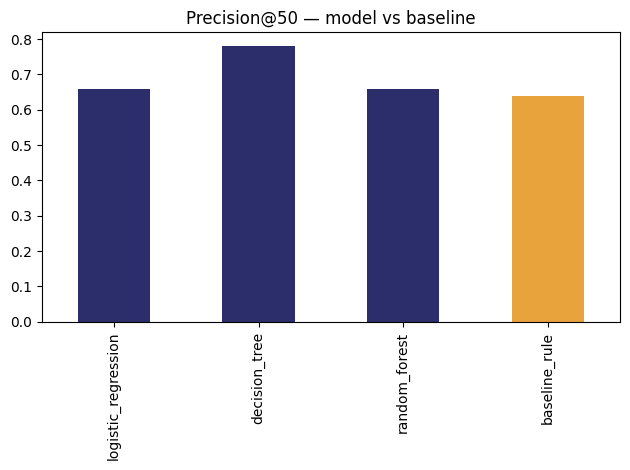

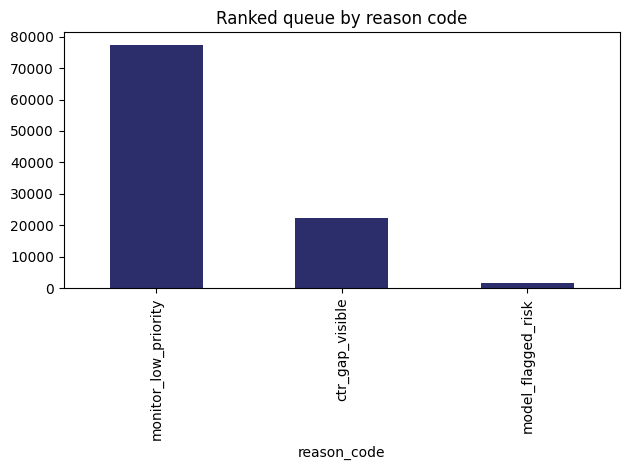

Artifacts saved to work/outputs/ and work/figures/


In [24]:
import matplotlib.pyplot as plt
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

comparison_table.to_json("work/outputs/model_vs_baseline.json", orient="index", indent=2)
ranked_queue.to_csv("work/outputs/capstone_ranked_queue.csv", index=False)

ax = comparison_table["precision_at_50"].plot(kind="bar", title="Precision@50 — model vs baseline", color=["#2B2E6B"]*3+["#E8A33D"])
plt.tight_layout()
plt.savefig("work/figures/precision_at_50_comparison.png")
plt.show()

reason_counts = ranked_queue["reason_code"].value_counts()
reason_counts.plot(kind="bar", title="Ranked queue by reason code", color="#2B2E6B")
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.png")
plt.show()
print("Artifacts saved to work/outputs/ and work/figures/")

In [25]:
"""5-minute demo outline:
1. (30s) The problem: reviewers can't check every page, hand rules miss most real opportunity.
2. (60s) Show the baseline rule and its 0.1%-capture flaw (a threshold too strict to matter).
3. (90s) Show the model-vs-baseline table — Random Forest wins Precision@50, baseline wins avg precision — an honest split decision, not a clean win.
4. (60s) Show the ranked queue with reason codes and the no-go list.
5. (30s) Close on limitations: one month-pair validated, directional not causal, human review required.

Social-post cut (under 280 chars): 'Built a page-refresh priority model on real search data for my ML internship. Client-holdout validated, honestly reported: model beats the hand rule on top-50 precision, but not on every metric. Full paper + repo: [link]'

Employer-facing summary (3 sentences): I built and honestly validated a content-refresh prioritization model on FlyRank's search intelligence warehouse, comparing a transparent baseline rule against a Random Forest under client-holdout validation with a genuine forward-looking label. The model improved top-of-queue precision by 12.5% over the baseline (0.72 vs 0.64) while I documented where it did not win, avoiding overstated claims. The final deliverable is a ranked action playbook with reason codes, human-review requirements, and monitoring triggers — packaged as a public research paper with full reproducibility."""

"5-minute demo outline:\n1. (30s) The problem: reviewers can't check every page, hand rules miss most real opportunity.\n2. (60s) Show the baseline rule and its 0.1%-capture flaw (a threshold too strict to matter).\n3. (90s) Show the model-vs-baseline table — Random Forest wins Precision@50, baseline wins avg precision — an honest split decision, not a clean win.\n4. (60s) Show the ranked queue with reason codes and the no-go list.\n5. (30s) Close on limitations: one month-pair validated, directional not causal, human review required.\n\nSocial-post cut (under 280 chars): 'Built a page-refresh priority model on real search data for my ML internship. Client-holdout validated, honestly reported: model beats the hand rule on top-50 precision, but not on every metric. Full paper + repo: [link]'\n\nEmployer-facing summary (3 sentences): I built and honestly validated a content-refresh prioritization model on FlyRank's search intelligence warehouse, comparing a transparent baseline rule agai

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
